In [2]:
!wget "https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip" -O dataset.zip

--2026-06-20 03:54:47--  https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
Resolving nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)... 16.15.212.156, 16.182.40.81, 16.15.237.197, ...
Connecting to nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)|16.15.212.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9188863364 (8.6G) [application/zip]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]   8.56G  46.2MB/s    in 3m 29s  

2026-06-20 03:58:16 (41.9 MB/s) - ‘dataset.zip’ saved [9188863364/9188863364]



In [3]:
!unzip dataset.zip


Archive:  dataset.zip
   creating: datasets/
   creating: datasets/minmax/
  inflating: datasets/minmax/dnn_scaled_data_cp_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_cp_train.pt  
  inflating: datasets/minmax/dnn_scaled_data_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_train.pt  
  inflating: datasets/minmax/graph_scaled_data_cp_test.pt  
  inflating: datasets/minmax/graph_scaled_data_cp_train.pt  
  inflating: datasets/minmax/graph_scaled_data_test.pt  
  inflating: datasets/minmax/graph_scaled_data_train.pt  
   creating: datasets/standard/
  inflating: datasets/standard/dnn_scaled_data_cp_test.pt  
  inflating: datasets/standard/dnn_scaled_data_cp_train.pt  
  inflating: datasets/standard/dnn_scaled_data_test.pt  
  inflating: datasets/standard/dnn_scaled_data_train.pt  
  inflating: datasets/standard/graph_scaled_data_cp_test.pt  
  inflating: datasets/standard/graph_scaled_data_cp_train.pt  
  inflating: datasets/standard/graph_scaled_data_test.pt  
  inflati

In [4]:
!find . -name "*.pt"


./datasets/standard/graph_scaled_data_cp_train.pt
./datasets/standard/graph_scaled_data_test.pt
./datasets/standard/graph_scaled_data_train.pt
./datasets/standard/dnn_scaled_data_test.pt
./datasets/standard/dnn_scaled_data_cp_test.pt
./datasets/standard/dnn_scaled_data_cp_train.pt
./datasets/standard/dnn_scaled_data_train.pt
./datasets/standard/graph_scaled_data_cp_test.pt
./datasets/minmax/graph_scaled_data_cp_train.pt
./datasets/minmax/graph_scaled_data_test.pt
./datasets/minmax/graph_scaled_data_train.pt
./datasets/minmax/dnn_scaled_data_test.pt
./datasets/minmax/dnn_scaled_data_cp_test.pt
./datasets/minmax/dnn_scaled_data_cp_train.pt
./datasets/minmax/dnn_scaled_data_train.pt
./datasets/minmax/graph_scaled_data_cp_test.pt


In [5]:
import torch

train = torch.load(
    "datasets/standard/dnn_scaled_data_train.pt",
    map_location="cpu"
)

test = torch.load(
    "datasets/standard/dnn_scaled_data_test.pt",
    map_location="cpu"
)

print("Train samples:", len(train))
print("Test samples:", len(test))

Train samples: 537979
Test samples: 230563


In [6]:
x, y = train[0]

print(x.shape)
print(y.shape)

torch.Size([201])
torch.Size([102])


In [9]:
import numpy as np

N = 10000

X = np.stack([
    train[i][0].numpy()
    for i in range(N)
])

Y = np.stack([
    train[i][1].numpy()
    for i in range(N)
])

In [10]:
print(X.shape)
print(Y.shape)


(10000, 201)
(10000, 102)


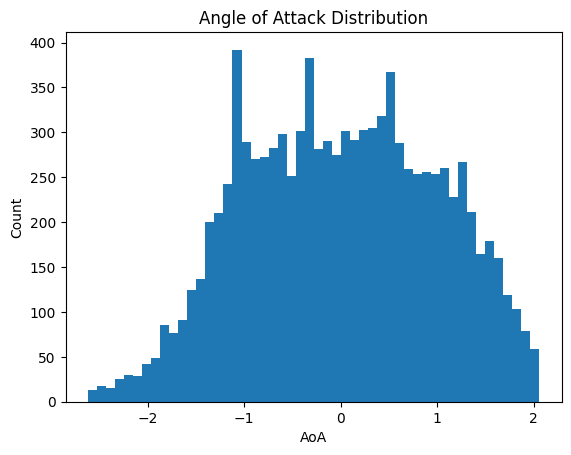

In [11]:
import matplotlib.pyplot as plt

plt.hist(X[:,198], bins=50)
plt.title("Angle of Attack Distribution")
plt.xlabel("AoA")
plt.ylabel("Count")
plt.show()


In [12]:
plt.savefig("aoa_distribution.png")

<Figure size 640x480 with 0 Axes>

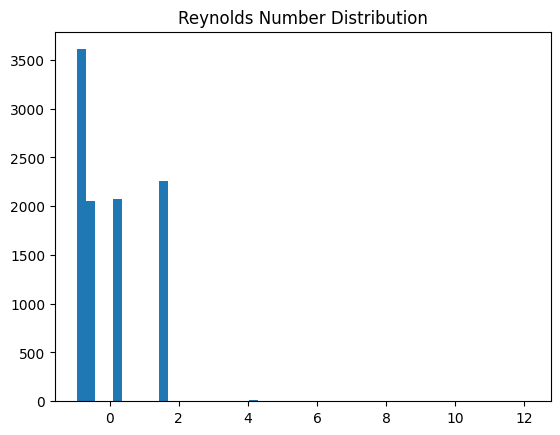

In [13]:
plt.hist(X[:,199], bins=50)
plt.title("Reynolds Number Distribution")
plt.show()

In [14]:
plt.savefig("reynolds_distribution.png")


<Figure size 640x480 with 0 Axes>

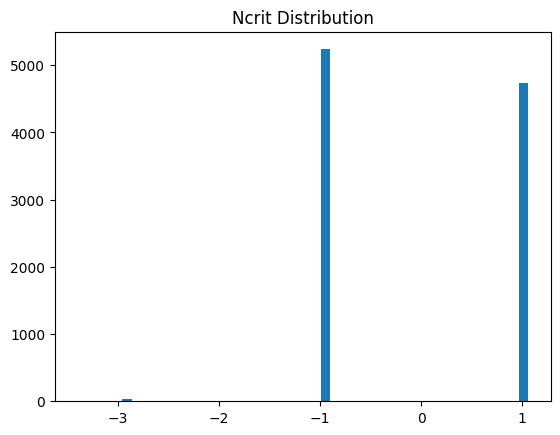

In [15]:
plt.hist(X[:,200], bins=50)
plt.title("Ncrit Distribution")
plt.show()


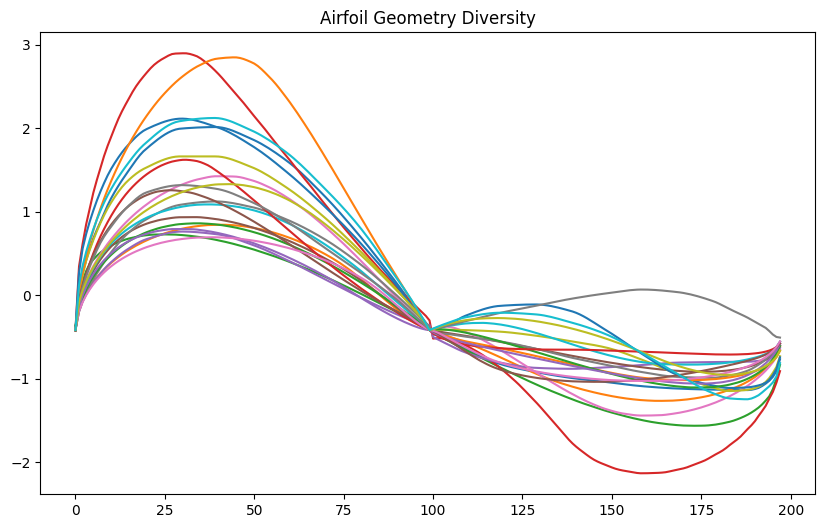

In [16]:
plt.figure(figsize=(10,6))

for i in range(20):
    plt.plot(X[i,:198])

plt.title("Airfoil Geometry Diversity")
plt.show()

In [17]:
plt.savefig("geometry_diversity.png")

<Figure size 640x480 with 0 Axes>

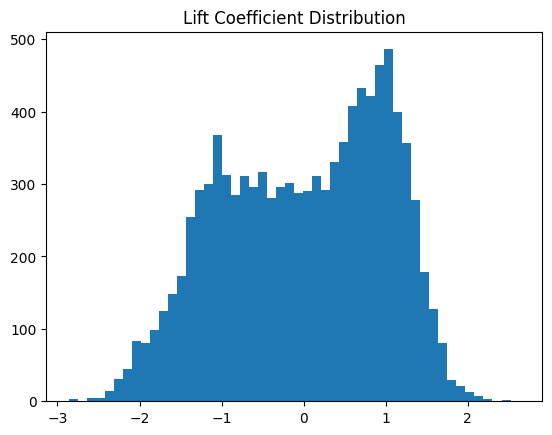

In [18]:
Cl = Y[:,0]

plt.hist(Cl,bins=50)
plt.title("Lift Coefficient Distribution")
plt.show()

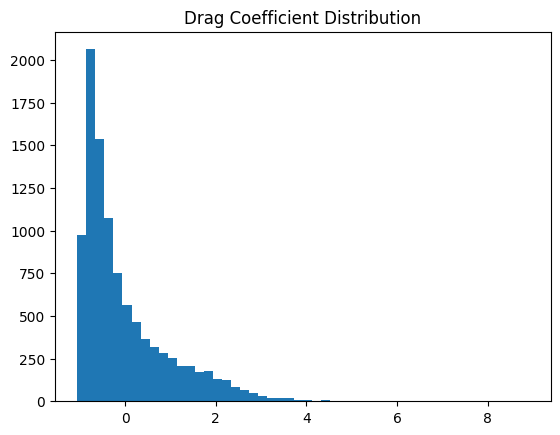

In [19]:
Cd = Y[:,1]

plt.hist(Cd,bins=50)
plt.title("Drag Coefficient Distribution")
plt.show()


In [20]:
cp = Y[0,4:]

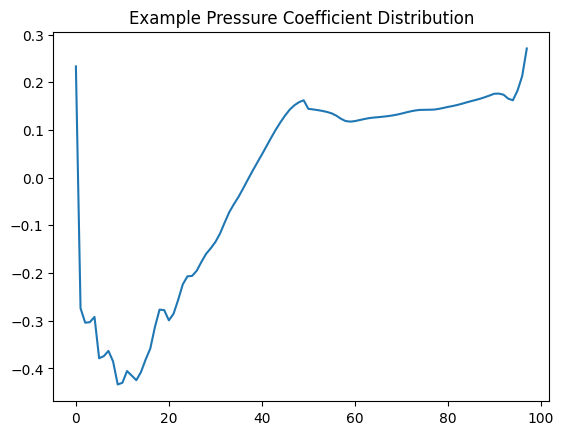

In [21]:
plt.plot(cp)
plt.title("Example Pressure Coefficient Distribution")
plt.show()

In [22]:
plt.savefig("cp_example.png")

<Figure size 640x480 with 0 Axes>

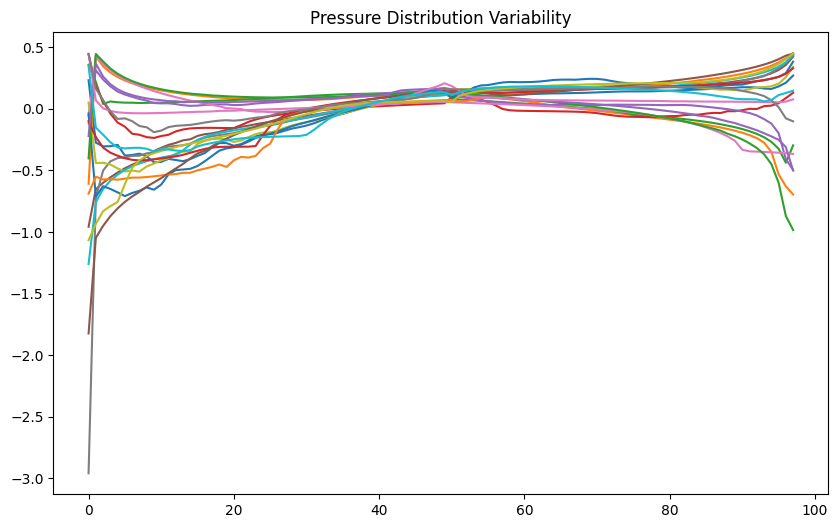

In [23]:
plt.figure(figsize=(10,6))

for i in range(20):
    plt.plot(Y[i,4:])

plt.title("Pressure Distribution Variability")
plt.show()

In [24]:
plt.savefig("cp_variability.png")

<Figure size 640x480 with 0 Axes>

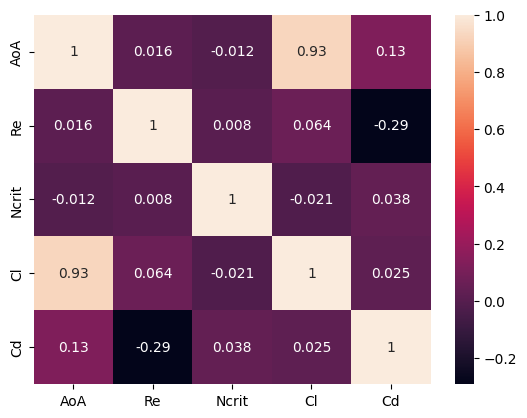

In [25]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
    "AoA": X[:,198],
    "Re": X[:,199],
    "Ncrit": X[:,200],
    "Cl": Y[:,0],
    "Cd": Y[:,1]
})

corr = df.corr()

sns.heatmap(corr,annot=True)
plt.show()

In [26]:
plt.savefig("correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [27]:
np.isnan(X).sum()

np.int64(0)

In [28]:
np.isnan(Y).sum()

np.int64(0)

In [29]:
np.unique(X,axis=0).shape

(10000, 201)

In [30]:
X.shape


(10000, 201)